# Pré-processamento dos Áudios

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

import json
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

from modules.datasets import ICBHIAudioDataset, KAUHAudioDataset, CombinedAudioDataset
from modules.lungsound import LungSoundAudio
from modules.transforms import *

In [2]:
DATA_PATH = Path(os.path.join(os.path.dirname(os.getcwd()), "data"))
RAW_DATA_FOLDER = DATA_PATH / "raw"
INTERIM_DATA_FOLDER = DATA_PATH / "interim"

if not os.path.exists(RAW_DATA_FOLDER):
    raise FileNotFoundError(f"Raw data folder not found at {RAW_DATA_FOLDER}. Please ensure the original data was already downloaded and placed in the correct location.")

if not os.path.exists(INTERIM_DATA_FOLDER):
    os.makedirs(INTERIM_DATA_FOLDER)
    print(f"Created interim data folder at {INTERIM_DATA_FOLDER}.")

## Interim

In [ ]:
TARGET_SR = 22050           # Hz
WINDOW_LENGTH = 5           # seconds
STANDARD_HOP_LENGTH = 2.5   # 50% overlap
COPD_HOP_LENGTH = 5         # no overlap

# NOTE: For COPD, we will not apply any overlap between windows to undersample this class, which is overrepresented in the dataset.

def preprocess_audios(original_data_path: Path, preprocessed_data_path: Path):
    """
    Preprocesses the original data and saves the preprocessed data to the specified location using multiple feature extractors.
    Args:
        original_data_path (Path): Path to the original raw data.
        preprocessed_data_path (Path): Path where the preprocessed data will be saved.
    """

    datasets = [
        ICBHIAudioDataset(original_data_path),
        KAUHAudioDataset(original_data_path)
    ]

    # Iterate through each dataset and apply preprocessing to the audio files
    for dataset in datasets:
        df = dataset.data
        new_rows = []
        for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Preprocessing {dataset.__class__.__name__}"):
            file_path = dataset.root / row["FilePath"]
            diagnosis = row["Diagnosis"]
            # Load the audio file using the LungSound class
            audio = LungSoundAudio(str(file_path))
            # Apply audio transforms
            # 1. Split the audio into windows of fixed duration
            HOP_LENGTH = COPD_HOP_LENGTH if diagnosis == "COPD" else STANDARD_HOP_LENGTH
            cropped_audios = Window(window_length=WINDOW_LENGTH, hop_length=HOP_LENGTH)(audio)
            for i, cropped_audio in enumerate(cropped_audios):
                # 2. Resample the audio to the target sampling rate
                resampled_audio = Resample(target_sr=TARGET_SR)(cropped_audio)
                # 3. Normalize the audio
                normalized_audio = NormalizeAudio()(resampled_audio)
                # Save the preprocessed audio to the new location
                start = i * HOP_LENGTH
                end = start + WINDOW_LENGTH
                preprocessed_file_name = f"{file_path.stem}_clip-{start:.1f}s-{end:.1f}s.wav"
                preprocessed_file_path = preprocessed_data_path / dataset.name / diagnosis / preprocessed_file_name 
                preprocessed_file_path.parent.mkdir(parents=True, exist_ok=True)
                sf.write(preprocessed_file_path, normalized_audio.audio, normalized_audio.sr)

                # Create a new row for the preprocessed audio file with the same metadata as the original row
                new_row = row.copy()
                relpath = preprocessed_file_path.relative_to(preprocessed_data_path)
                new_row["FilePath"] = relpath
                new_rows.append(new_row)
            
        # Save the new rows to a new dataframe and then to a new CSV file
        data_path = preprocessed_data_path / dataset.name / f"metadata.csv"
        new_df = pd.DataFrame(new_rows)
        new_df.to_csv(data_path, index=False)

        print(f"Processed {len(df)} original audio files from {dataset.__class__.__name__}.")
        print(f"Created {len(new_rows)} preprocessed audio files for {dataset.__class__.__name__}.")

        # Save the audio preprocessing informations to a JSON file
        audio_transforms = {
            Window.__name__: {"params": vars(Window(window_length=WINDOW_LENGTH, hop_length=STANDARD_HOP_LENGTH))},
            Resample.__name__: {"params": vars(Resample(target_sr=TARGET_SR))},
            NormalizeAudio.__name__: {"params": vars(NormalizeAudio())},
        }
        json_path = preprocessed_data_path / dataset.name / "audio_preprocessing.json"
        notes = f"For COPD, we applied a different hop length of {COPD_HOP_LENGTH} seconds to undersample this class."
        preprocessing = {
            "audio_transforms": audio_transforms,
            "NOTES": notes
        }
        with open(json_path, "w") as f:
            json.dump(preprocessing, f, indent=4)

    print("-------------------------------------------------------")
    print(f"Preprocessing for {original_data_path.name} completed.")
    print(f"Data saved to {os.path.relpath(preprocessed_data_path, start=os.getcwd())}")

In [ ]:
preprocess_audios(RAW_DATA_FOLDER, INTERIM_DATA_FOLDER)

## Verificando a distribuição do Dataset

Combined dataset contains 5962 samples.


Diagnosis
COPD                3487
Healthy              828
Asthma               520
Pneumonia            355
Heart Failure        252
URTI                 159
Bronchiectasis       112
Bronchiolitis         91
Lung Fibrosis         57
Pleural Effusion      51
Bronchitis            36
LRTI                  14
Name: count, dtype: int64

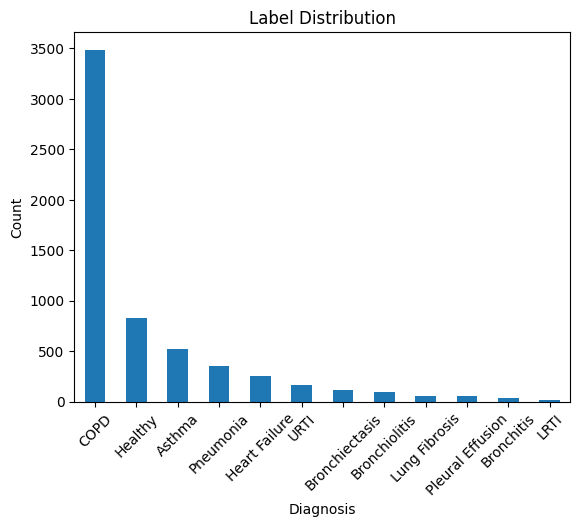

Combined dataset contains 1244 samples.


In [3]:
def plot_label_distribution(df):
    """
    Plot the distribution of labels in the dataset.
    Args:
        df (pd.DataFrame): The DataFrame containing label information.
    """
    label_counts = df["Diagnosis"].value_counts()
    display(label_counts)
    label_counts.plot(kind="bar")
    plt.title("Label Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
    
combined_dataset = CombinedAudioDataset(INTERIM_DATA_FOLDER, split="all")
print(f"Combined dataset contains {len(combined_dataset)} samples.")

plot_label_distribution(combined_dataset.data)


combined_dataset = CombinedAudioDataset(RAW_DATA_FOLDER, split="all")
print(f"Combined dataset contains {len(combined_dataset)} samples.")

TRAIN DATASET
Combined train dataset contains 4411 samples.


Diagnosis
COPD              2786
Healthy            658
Asthma             412
Pneumonia          257
URTI               125
Bronchiectasis      84
Bronchiolitis       56
Lung Fibrosis       33
Name: count, dtype: int64

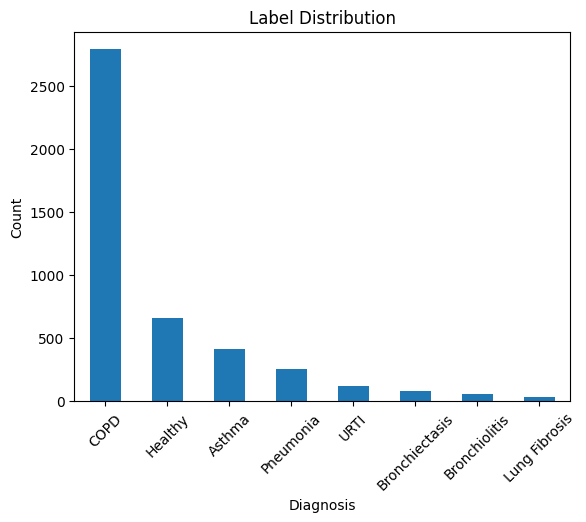

VALIDATION DATASET
Combined validation dataset contains 623 samples.


Diagnosis
COPD              351
Healthy            85
Pneumonia          63
Asthma             54
Bronchiolitis      21
URTI               20
Lung Fibrosis      15
Bronchiectasis     14
Name: count, dtype: int64

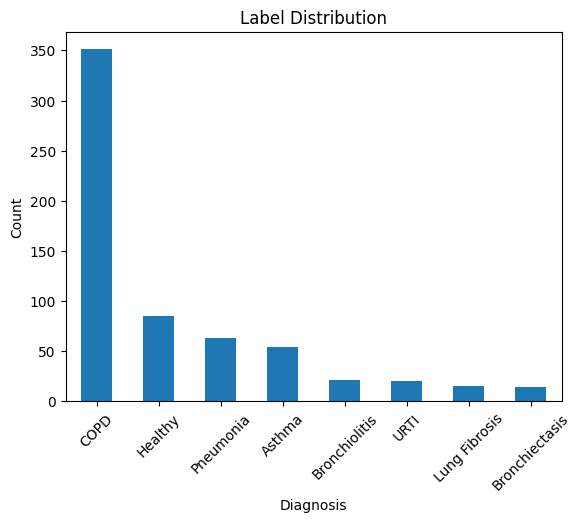

TEST DATASET
Combined test dataset contains 575 samples.


Diagnosis
COPD              350
Healthy            85
Asthma             54
Pneumonia          35
URTI               14
Bronchiectasis     14
Bronchiolitis      14
Lung Fibrosis       9
Name: count, dtype: int64

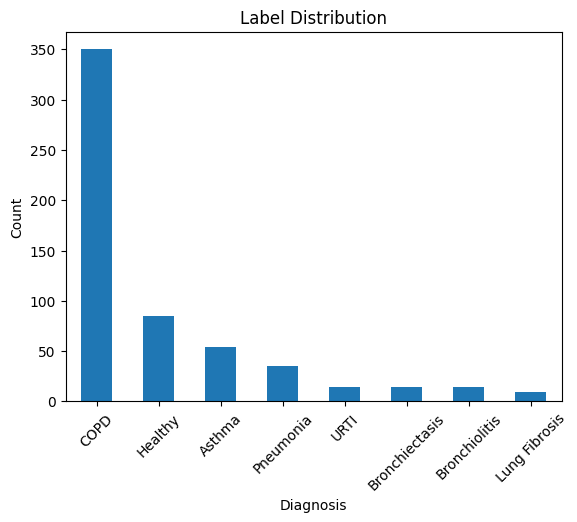

In [5]:
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    "COPD",
    "Healthy",
    "Lung Fibrosis",
    "Pneumonia",
    "URTI",
]

combined_train_dataset = CombinedAudioDataset(INTERIM_DATA_FOLDER, split="train", classes=SELECTED_CLASSES)
print(f"{'='*20}\nTRAIN DATASET\n{'='*20}")
print(f"Combined train dataset contains {len(combined_train_dataset)} samples.")
plot_label_distribution(combined_train_dataset.data)

combined_val_dataset = CombinedAudioDataset(INTERIM_DATA_FOLDER, split="val", classes=SELECTED_CLASSES)
print(f"{'='*20}\nVALIDATION DATASET\n{'='*20}")
print(f"Combined validation dataset contains {len(combined_val_dataset)} samples.")
plot_label_distribution(combined_val_dataset.data)

combined_test_dataset = CombinedAudioDataset(INTERIM_DATA_FOLDER, split="test", classes=SELECTED_CLASSES)
print(f"{'='*20}\nTEST DATASET\n{'='*20}")
print(f"Combined test dataset contains {len(combined_test_dataset)} samples.")
plot_label_distribution(combined_test_dataset.data)